# Reduce one raster position: is a lattice, or an a/b splitting, resolvable here?

Determines the lattice at ONE position of a raster scan of a single crystal or a few domains
-- ingest, index every domain, audit completeness and honesty, and (if the gates allow it)
refine an a/b splitting with a bootstrap error bar. Built entirely on `midas_defect`/`midas_hkls`
package functions documented in `manuals/defect/` and `manuals/solve-cell/` -- this notebook
is a thin, annotated driver, not new science.

**This is the single-point half.** For a whole raster (one point or all of them, sharded for a
large scan), see `06_raster_lattice_batch.ipynb`. Read that notebook's closing cell before
trusting an a/b splitting from THIS one alone: a single position's gates cannot rule out a
common radial-systematic artifact across domains -- only a raster-wide check can (see the note
in Step 2's output when it applies).

**No material default anywhere.** Six `midas_defect.rows` functions default to one DAC sample's
cell (`manuals/solve-cell/PACKAGE_NOTES.md` §2); this notebook and the functions it calls
require yours explicitly, every time.


## Step 0 — CONFIG

Set your material (no default), your geometry, and how to load one position's frames. With no
`LOADER` set, this notebook runs on a synthetic position with a known planted answer
(`midas_defect.synthetic.synthetic_position_frames`) -- built from the SAME geometry primitives
(`ewald_crossing_omegas`, `qsample_to_qlab`, `qlab_to_pixel`) the real ingest chain and
`find_domains` consume, and pushed through the real ingest chain too (mask, background,
blob-finding, powder separation) -- so every cell below shows real output with no download.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import midas_defect as dx
from midas_defect.geometry import Geometry
from midas_defect.raster import reduce_one_position

# ---- the only lines you change ------------------------------------------------------
A, C = 4.0, 10.0                  # YOUR material's cell (fictional example values here)
SPACE_GROUP_NUMBER = 123          # YOUR space group (P4/mmm here -- purely illustrative)
SIGMA_RTN = (0.02, 0.02, 0.02)    # YOUR measured (radial, transverse, normal) residual budget,
                                   # in 1/A -- see manuals/solve-cell/phase-3-refine.md. The
                                   # package default (0.0071, 0.0145, 0.0094) is one DAC
                                   # sample's, not yours.
GEOM = None                        # a midas_defect.geometry.Geometry -- e.g.
                                   # Geometry.from_paramstest("parameters_final.txt") -- or
                                   # None for the synthetic fallback below
LOADER = None                      # LOADER(p) -> (n_frames, n_rows, n_cols) raw frame stack
                                   # for raster position p, or None for the synthetic fallback
POINT = 0                          # which position to reduce
ORIENTATION_ENVELOPE = False        # SKETCH, 2026-09-13: also bootstrap each domain's
                                    # own orientation fit and report its spread (Step 5
                                    # below). Off by default -- re-runs the orientation
                                    # refit N_ORIENTATION_BOOT times PER DOMAIN, on top
                                    # of everything else this notebook already does.
N_ORIENTATION_BOOT = 25

# --- pointing LOADER at REAL frames: the one non-obvious step (validated on a real 2604
# raster position, 2026-09-12). A raw stack usually has dead/shutter-ramp frames at the ends
# (partial-exposure frames from the shutter opening/closing) that must come OUT before this
# function sees them, and GEOM.omega_first_deg must be remapped to whichever raw frame ends up
# first -- reduce_one_position maps frame index -> omega directly, with no dead-frame logic of
# its own. Sketch (fill in your own file naming):
#
#   from midas_defect.ingest import live_frames
#   RAW_OMEGA0, DOMEGA = -19.5, 1.0             # your own scan's raw omega program
#   def LOADER(p):
#       raw = np.stack([tifffile.imread(my_path(p, k)) for k in range(N_RAW_FRAMES)])
#       live, _ = live_frames(raw)                          # drops dead/shutter-ramp frames
#       first = int(np.flatnonzero(live)[0])
#       GEOM.omega_first_deg = RAW_OMEGA0 + DOMEGA * first   # remap to the first LIVE frame
#       return raw[live]
#
# `live_frames` decides per POSITION, so a real raster's positions can end up with different
# frame counts -- fine here (05 reduces one point), but `06_raster_lattice_batch.ipynb`'s
# `reduce_raster_block` takes ONE shared GEOM for the whole raster: check that every position
# you batch drops the same number of leading/trailing frames before assuming one GEOM covers
# all of them (it did for five real 2604 positions checked this way; it need not for yours).
# ---------------------------------------------------------------------------------------

if GEOM is None:
    GEOM = Geometry(lsd_um=120_000.0, bcy_px=384.0, bcz_px=384.0, px_um=172.0,
                    wavelength_A=0.4246, n_pix_y=768, n_pix_z=768,
                    omega_first_deg=-19.5, omega_step_deg=1.0, n_frames=40,
                    label="synthetic example")
    print("No GEOM set: using a synthetic example geometry.")

if LOADER is None:
    from scipy.spatial.transform import Rotation
    from midas_defect.synthetic import synthetic_position_frames
    B_TRUTH = 3.9   # the synthetic fallback's own planted b -- real data has no such thing
    U_TRUTH = Rotation.from_euler("zyx", [15.0, 25.0, -8.0], degrees=True).as_matrix()

    def LOADER(p, _seed=[0]):
        frames, truth = synthetic_position_frames(
            [U_TRUTH], a=A, b=B_TRUTH, c=C, space_group_number=SPACE_GROUP_NUMBER, geom=GEOM,
            hmax=8, kmax=8, lmax=14, seed=p)
        LOADER.truth = truth
        return frames
    print(f"No LOADER set: using a synthetic position with a known answer "
         f"(a={A}, b={B_TRUTH}, c={C}, split={100*(A-B_TRUTH)/B_TRUTH:.3g} %).")

frames = LOADER(POINT)
print(f"point {POINT}: frames {frames.shape}, {frames.dtype}")


No GEOM set: using a synthetic example geometry.
No LOADER set: using a synthetic position with a known answer (a=4.0, b=3.9, c=10.0, split=2.56 %).


point 0: frames (40, 768, 768), float32


## Step 1 — Reduce: ingest, index, audit, refine

`reduce_one_position` runs the whole documented chain in order (`manuals/defect/phase-1-ingest.md`,
`phase-2-index.md`; `manuals/solve-cell/phase-3-refine.md`):

1. **ingest** (mask, background, 3-D blob-finding, powder separation) -- `manuals/defect/phase-1-ingest.md`;
2. an **ω-sign check** (does `find_domains` explain more spots under +ω or −ω?);
3. **`find_domains`**: every crystal domain at this position, row-seeded first, then pair-seeded;
4. per domain: **completeness** (INDEXED/MISSED/MASKED/ABSENT), **honesty** (`decoy_test`,
   `feature_in_raw`), and the **a/b gate chain** (`ab_separable` → `partner_multiplicity` →
   `index_asymmetry` → `shear_separable`);
5. for every domain that passes the gate chain: `refine_cell_joint` with a bootstrap error bar,
   and `split_with_error`.

`res.quotable` distills all of this into one flag -- but read `res.notes` for WHY, not just the
answer. Nothing here overrides a failed gate.


In [2]:
res = reduce_one_position(frames, GEOM, a=A, c=C, space_group_number=SPACE_GROUP_NUMBER,
                          sigma_rtn=SIGMA_RTN, point=POINT, n_bootstrap=300,
                          orientation_uncertainty=ORIENTATION_ENVELOPE,
                          n_orientation_boot=N_ORIENTATION_BOOT)
print(res.summary())


position 0: 328 spots, omega sign +1 (omega +1: 322 spots explained, omega -1: 0 spots explained)
1 domain(s) found
  domain 0: completeness {'INDEXED': 321, 'MISSED': 6, 'MASKED': 0, 'ABSENT': 0}; honesty informative; feature-in-raw in_raw; ab gate: {'n_k_gt_h': 24, 'n_h_gt_k': 252, 'ratio': 0.09523809523809523, 'sigma_ratio': 0.425292454415503}
  domain 0: targeted recovery 4/4 of 6 missed sites (excess 9.8 sigma over the same-ring null)
a/b split: 2.61 % +/- 0.0173 % (z=1.5e+02)
quotable: True
note: domain 0: index_asymmetry ratio 0.0952 is far from 1 (measured 5x on the 2604 raster was the signature of a radial-systematic artifact, not a real splitting). A SINGLE position cannot rule this out -- 'a common sign across domains is physically impossible' only becomes checkable with several positions/domains; see the raster-wide check.


## Step 2 — Look at the frames: where are the claimed reflections?

The max-intensity projection over all frames, with every domain's CLAIMED spots marked. If a
domain's spots do not sit on real, visible features here, something upstream is wrong no matter
what the numbers below say -- this is the same discipline as DFXM's B4 ("does the map deserve
trust? look at the curves"): read the picture before the summary.


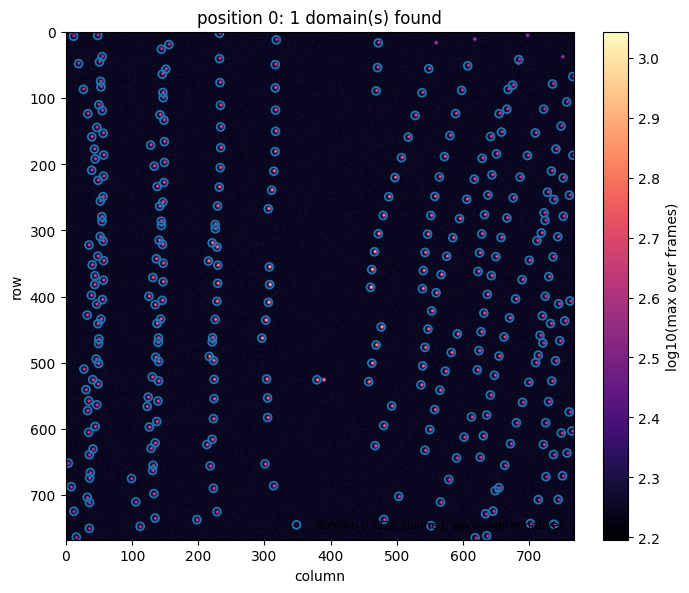

In [3]:
from midas_defect.raster import plot_domain_overlay

fig = plot_domain_overlay(frames, res, GEOM)
plt.show()

if not res.domains.domains:
    print("No domains found at this position -- nothing to overlay. See res.notes.")

## Step 3 — Completeness, honesty, and the a/b gate chain, per domain

**Completeness** (INDEXED/MISSED/MASKED/ABSENT): MISSED should be 0 or small -- a predicted
reflection with a real spot nearby that the solver did not assign is a sign something is off.

**Honesty**: `decoy_test` asks whether a deliberately WRONG cell (a few percent off) also
explains this domain's reflections about as well -- if so, passing means nothing.
`feature_in_raw` asks whether the brightest claimed reflection is a real feature in the RAW
frames, not something background subtraction created.

**The a/b gate chain**, in the required order (`manuals/solve-cell/phase-3-refine.md`):
`ab_separable` (rank ≥ 2, necessary not sufficient) → `partner_multiplicity` (a pair on
≤ 1 spot on one side is one blob-finding decision from nothing) → `index_asymmetry`
(a design skewed toward one axis biases the fitted split, with a consistent SIGN across
domains as the signature) → `shear_separable`. A domain only reaches `refine_cell_joint` if
it passes every stage.


In [4]:
for i, (aud, dec, fr, gate) in enumerate(zip(res.completeness, res.decoy,
                                             res.feature_in_raw, res.ab_gates)):
    print(f"--- domain {i} ---")
    print("completeness:", aud.counts)
    print("honesty (decoy_test):", dec["verdict"],
         f"(real {dec['real']:.0f} vs threshold {dec['threshold']:.0f}; "
         f"decoys passing: {dec['decoys_passing'] or 'none'})")
    print("feature in raw frames:", fr["verdict"])
    print("a/b gate:", gate.get("stage") or "passed every stage", "--", gate.get("reason"))
    print()

if res.notes:
    print("NOTES:")
    for n in res.notes:
        print(" -", n)


--- domain 0 ---
completeness: {'INDEXED': 321, 'MISSED': 6, 'MASKED': 0, 'ABSENT': 0}
honesty (decoy_test): informative (real 321 vs threshold 304; decoys passing: none)
feature in raw frames: in_raw
a/b gate: index_asymmetry -- {'n_k_gt_h': 24, 'n_h_gt_k': 252, 'ratio': 0.09523809523809523, 'sigma_ratio': 0.425292454415503}

NOTES:
 - domain 0: index_asymmetry ratio 0.0952 is far from 1 (measured 5x on the 2604 raster was the signature of a radial-systematic artifact, not a real splitting). A SINGLE position cannot rule this out -- 'a common sign across domains is physically impossible' only becomes checkable with several positions/domains; see the raster-wide check.


## Step 4 — The refined cell, if one was possible

`split_with_error` returns `(delta_percent, sigma_percent, z)`. `sigma` is NaN when the
symmetry being fitted forces a = b (nothing was measured, it was imposed) -- that is a
different thing from "no domain passed the gate chain" (`res.refined_cell is None`).


In [5]:
if res.refined_cell is not None:
    a_fit, b_fit, c_fit, alpha, beta, gamma = res.refined_cell
    print(f"refined cell: a={a_fit:.5f}  b={b_fit:.5f}  c={c_fit:.5f}  "
         f"(alpha={alpha:.3f} beta={beta:.3f} gamma={gamma:.3f} deg)")
    delta, sigma, z = res.split_pct
    print(f"a/b split: {delta:.3g} % +/- {sigma:.3g} % (z = {z:.3g})")
    if not np.isfinite(sigma):
        print("sigma is NaN: a and b are equal by the fitted symmetry -- nothing was measured.")
else:
    print("No domain passed the a/b gate chain at this position: no cell was jointly refined.")
print()
print("QUOTABLE:", res.quotable)


refined cell: a=3.89939  b=4.00255  c=9.99968  (alpha=90.000 beta=90.000 gamma=90.000 deg)
a/b split: 2.61 % +/- 0.0173 % (z = 151)

QUOTABLE: True


## Step 5 — The orientation envelope, if requested

The same "report the spread, not just the point estimate" discipline Step 4 applies to the
cell (`refine_cell_joint`'s bootstrap, surfaced via `split_with_error`), extended to
orientation: `seed_index.bootstrap_orientation_uncertainty` resamples each domain's claimed
reflections and refits `U` from scratch each time, reporting the pairwise misorientation
spread across those refits. Only computed if `ORIENTATION_ENVELOPE = True` in Step 0's
CONFIG (off by default -- it is not free, see that cell's comment).

**`/verify` REFUTED an earlier version of this on real La3Ni2O7 2601_LT data (claim
`b82502d6b5ad`): a sparse domain's wider envelope is NOT by itself "a real signal of
orientation determinability."** It can come from (1) a domain the pipeline's own honesty
gate (`decoy_test`, Step 3) does not trust in the first place, (2) generic 1/sqrt(n)
bootstrap scaling that any fit shows regardless of data quality, or (3) too few reflections
to draw independent bootstrap resamples at all -- the cell below prints `independent_resamples`
for exactly this reason. **Always read a domain's `decoy` verdict (Step 3) alongside its
orientation envelope, never instead of it.**

In [6]:
if not ORIENTATION_ENVELOPE:
    print("ORIENTATION_ENVELOPE is False (Step 0's CONFIG) -- nothing computed. "
         "Set it True and re-run to see this domain's orientation envelope.")
else:
    from midas_defect.raster import plot_orientation_envelope
    for i, oe in enumerate(res.orientation_envelope):
        if oe is None:
            print(f"domain {i}: not computed (fewer than 4 claimed reflections)")
            continue
        dom = res.domains.domains[i]
        print(f"domain {i}: {oe['n_boot']} bootstrap resamples, "
             f"keep_n={oe['keep_n']} of {len(dom.hkl)} claimed reflections")
        print(f"  pairwise misorientation: mean={oe['pair_angle_mean_deg']:.4f} deg  "
             f"p95={oe['pair_angle_p95_deg']:.4f} deg  max={oe['pair_angle_max_deg']:.4f} deg")
        print(f"  independent_resamples={oe['independent_resamples']} "
             f"(n_distinct_subsets={oe['n_distinct_subsets']} vs n_boot={oe['n_boot']})")
        if not oe['independent_resamples']:
            print("  WARNING: n_boot exceeds the number of distinct possible resamples -- "
                 "these are NOT independent looks at the data. Treat this spread as a lower "
                 "bound on how little this domain constrains its own orientation, not a "
                 "calibrated uncertainty.")
        print(f"  honesty check (Step 3) for this same domain: {res.decoy[i]['verdict']} -- "
             f"read this BEFORE trusting the envelope above, not after")
        print()
    fig = plot_orientation_envelope(res)
    plt.show()

ORIENTATION_ENVELOPE is False (Step 0's CONFIG) -- nothing computed. Set it True and re-run to see this domain's orientation envelope.


## Step 6 — The lattice envelope: a, b, c individually, not just the split

Step 4 already reports the a/b split with a bootstrap error bar, but that one number
collapses two lattice parameters into their difference. `refine_cell_joint` already
computes every bootstrap resample's full cell before reducing it to that difference --
`res.cell_bootstrap_samples` carries the raw (a, b, c, alpha, beta, gamma) array so you can
look at each parameter's own range, not only how far apart two of them are.

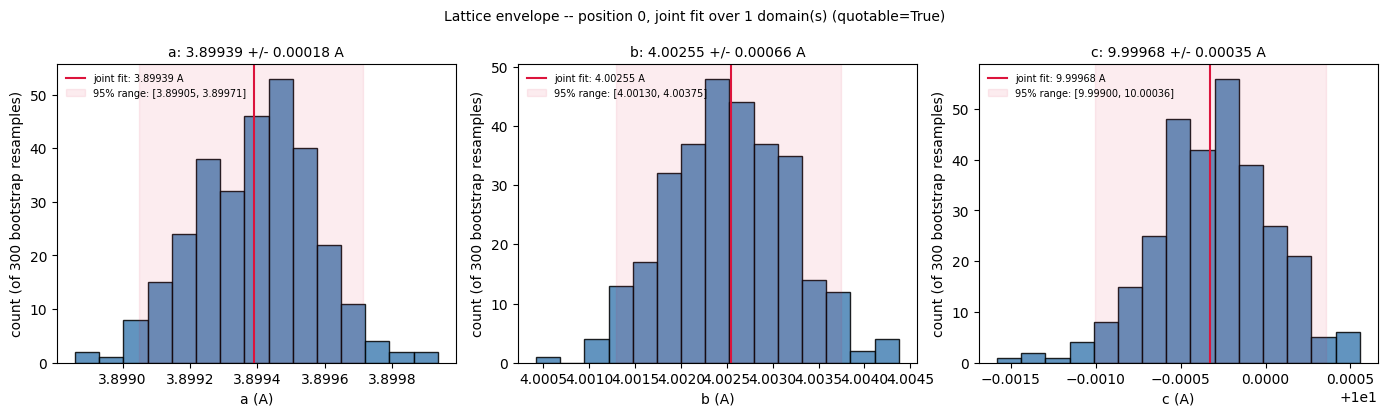

a: 3.89939 +/- 0.00018 A  (95% range [3.89905, 3.89971])
b: 4.00255 +/- 0.00066 A  (95% range [4.00130, 4.00375])
c: 9.99968 +/- 0.00035 A  (95% range [9.99900, 10.00036])


In [7]:
if res.cell_bootstrap_samples is None:
    print("No lattice bootstrap available -- no domain reached refine_cell_joint "
         "(res.refined_cell is None), or too few resamples succeeded.")
else:
    from midas_defect.raster import plot_lattice_envelope
    fig = plot_lattice_envelope(res)
    plt.show()
    samples = res.cell_bootstrap_samples
    for j, lab in enumerate(["a", "b", "c"]):
        lo, hi = np.percentile(samples[:, j], [2.5, 97.5])
        print(f"{lab}: {res.refined_cell[j]:.5f} +/- {res.cell_sigma_bootstrap[j]:.5f} A  "
             f"(95% range [{lo:.5f}, {hi:.5f}])")

## Step 7 — Visual check: does the refined cell actually predict where the spots are?

A direct, model-free sanity check on the dominant domain's fit: for 18 representative
reflections (a spread of `(00L)` that constrain `c` only, a-dominant and b-dominant
reflections that constrain `a`/`b` individually), crop a patch around the REAL observed
spot and overlay where TWO different cell refinements predict it should be. **Both are
shown side by side, deliberately, so you can judge which one you trust -- this notebook
does not pick a winner for you:**

- **joint** (`midas_hkls.cell_constrained.refine_cell_joint`): fits cell AND orientation
  together, from the full isotropic 3-vector `q_pred - q_obs` residual.
- **radial** (`refine_cell_radial`, the STAGED/iterative alternative): fits ONLY the cell,
  from the `|q|` magnitude residual alone -- exactly orientation-independent by
  construction (a rotation preserves vector norm), so it needs its own, SEPARATELY staged
  orientation for this plot: Stage A (`seed_index.refine_U_from_centroids`, a cosine-loss
  orientation-only refit, cell fixed at the NOMINAL seed -- not radial's own fitted cell,
  to keep the staging sequential rather than circular) runs first, then Stage B
  (`refine_cell_radial`) refines the cell alone. Pairing radial's cell with the domain's
  raw, never-refined indexed orientation (rather than this staged one) would be an unfair
  comparison -- joint gets a fitted orientation, radial should too.

Patches are **max-projected over each reflection's own frame extent** (`n_frames` from the
spot list), not a single arbitrary frame slice -- these reflections can be genuinely
elongated streaks spanning several frames, and a single-frame slice next to a full 3-D
centroid can make a correct centroid look wrong.

**Caveat, always read alongside this plot:** if this domain's `index_asymmetry` gate
(Step 3 above) is far from 1, both fits can still land close to their observed spots --
a plausible-looking overlay is necessary, not sufficient, evidence that a split is real.
Some claimed reflections have no valid predicted position under one or both hypotheses at
all (a real indexer/forward-model allowed-reflection mismatch, not silently hidden here)
and are excluded from the grid.

Using the dominant domain: 321 claimed reflections, branch=row


joint:  a=3.8994 b=4.0025 c=9.9997  split=2.611% +/- 0.018pp (z=148.31)
radial: a=3.8999 b=4.0000 c=10.0004  split=2.535% +/- 0.004pp (z=594.50)
Stage A orientation-only refit: cosine-loss=0.000054


211/321 claimed reflections have no valid predicted position under one or both hypotheses -- excluded below
selected 18 representative reflections


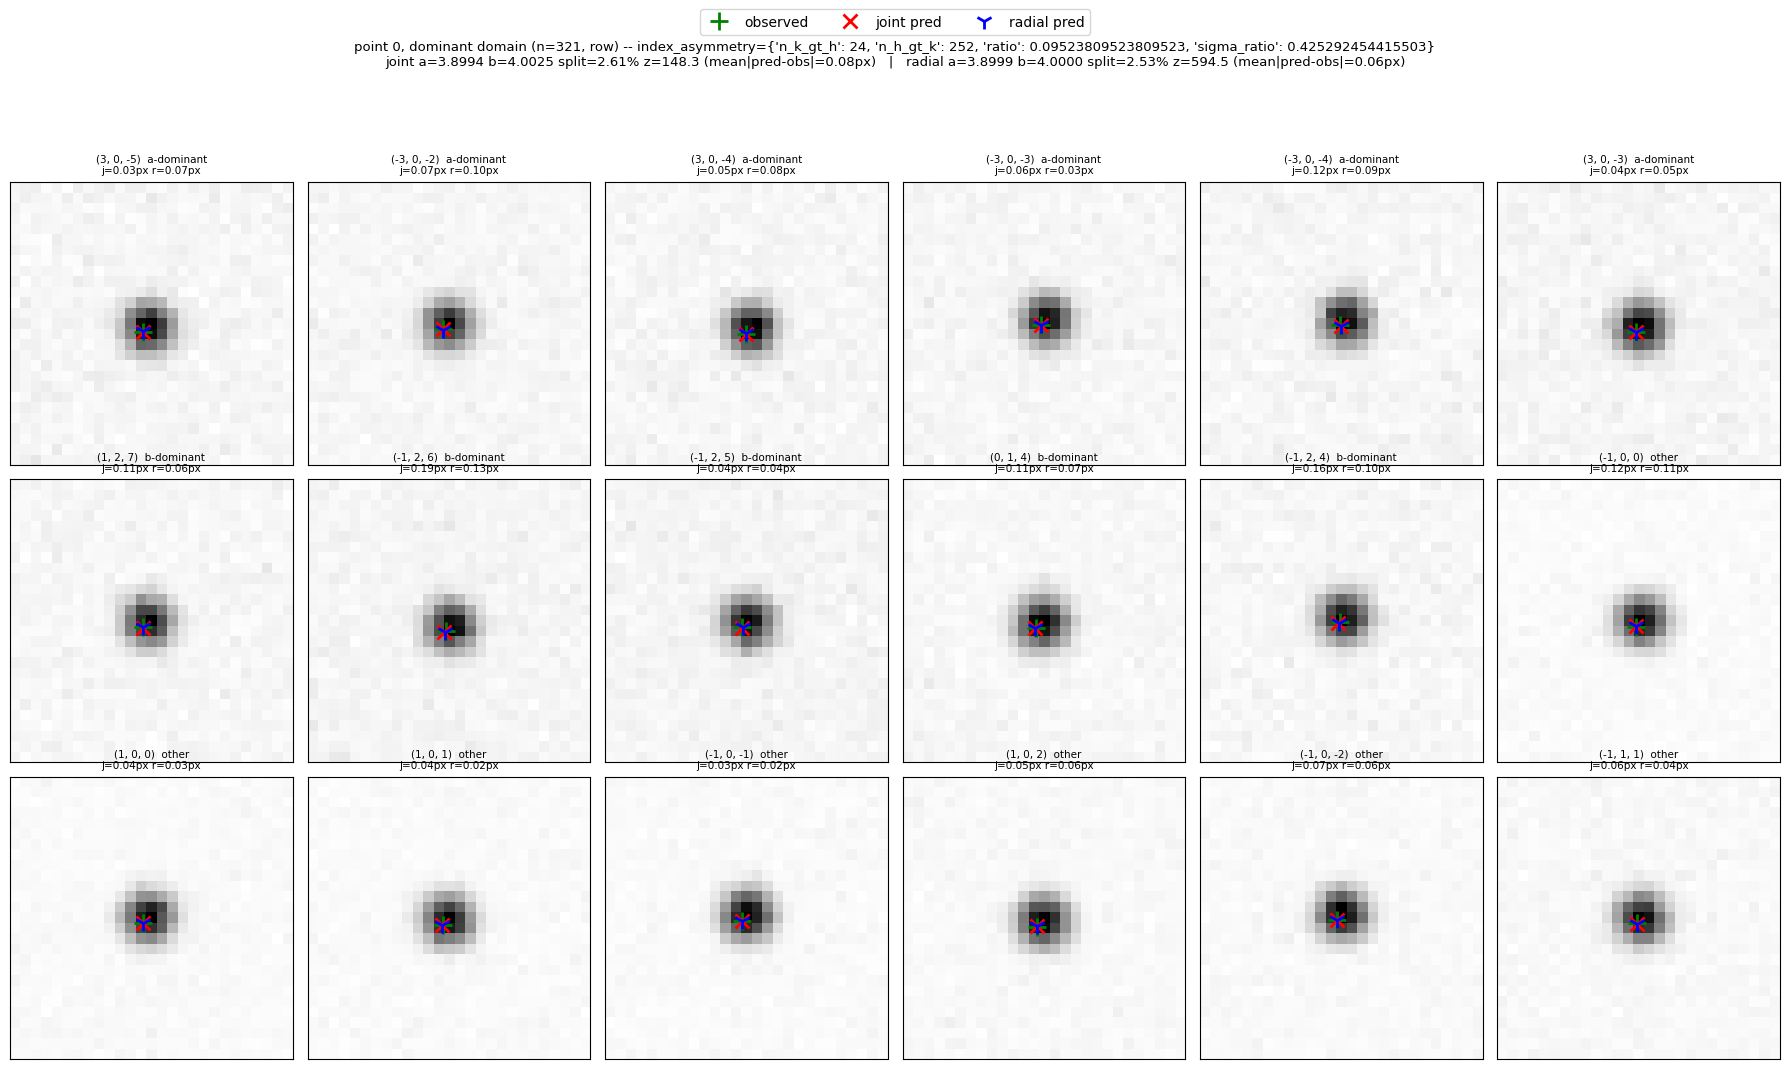

In [8]:
from midas_defect.raster import _ingest_position
from midas_defect.geometry import qlab_to_qsample
from midas_defect.indexing import build_forward_model, predict_spots
from midas_hkls.cell_constrained import (DomainData, refine_cell_joint, refine_cell_radial,
                                         _rotvec_to_R, split_with_error)
from midas_defect.seed_index import refine_U_from_centroids
import midas_hkls as mh
import torch, math

if not res.domains.domains:
    print("No domains found at this position -- nothing to check. See res.notes.")
else:
    DMIN = 1.10  # same d_min this project's other real-data scripts use
    dom = max(res.domains.domains, key=lambda d: d.n)  # the dominant domain
    dom_idx = res.domains.domains.index(dom)
    print(f"Using the dominant domain: {dom.n} claimed reflections, branch={dom.branch}")

    spots, qlab, omega_deg, mask, sub, _ = _ingest_position(frames, GEOM)
    claim = dom.claim
    row_obs_all = spots.row.values[claim]
    col_obs_all = spots.col.values[claim]
    frame_obs_all = spots.frame.values[claim].astype(float)
    n_frames_obs_all = spots.n_frames.values[claim].astype(int)
    hkl_all = dom.hkl
    q_all = qlab_to_qsample(qlab, torch.deg2rad(torch.as_tensor(
        res.omega_sign.chosen_sign * omega_deg, dtype=qlab.dtype))).detach().cpu().numpy()
    g_obs_domain = q_all[claim]

    SEED_CELL = (A, A, C, 90., 90., 90.)
    doms_ = [DomainData(hkl_all.astype(float), g_obs_domain)]
    fj = refine_cell_joint(doms_, system="orthorhombic", cell0=SEED_CELL, two_pi=True,
                           n_bootstrap=2000, rng=np.random.default_rng(0))
    fr = refine_cell_radial(doms_, system="orthorhombic", cell0=SEED_CELL, two_pi=True,
                            n_bootstrap=2000, rng=np.random.default_rng(0))
    U_joint = _rotvec_to_R(np.asarray(fj.rotvecs[0]))

    # Stage A for radial: orientation-only, cell fixed at the NOMINAL seed (not fr.cell)
    hkl_q_centroids = [(tuple(int(v) for v in hkl_all[i]), g_obs_domain[i]) for i in range(len(hkl_all))]
    U_radial, _, _, stageA_loss = refine_U_from_centroids(
        dom.U, hkl_q_centroids, a=A, b=A, c=C, refine_lattice=False)

    sj, sigj, zj = split_with_error(fj)
    sr, sigr, zr = split_with_error(fr)
    print(f"joint:  a={fj.cell[0]:.4f} b={fj.cell[1]:.4f} c={fj.cell[2]:.4f}  "
         f"split={sj:.3f}% +/- {sigj:.3f}pp (z={zj:.2f})")
    print(f"radial: a={fr.cell[0]:.4f} b={fr.cell[1]:.4f} c={fr.cell[2]:.4f}  "
         f"split={sr:.3f}% +/- {sigr:.3f}pp (z={zr:.2f})")
    print(f"Stage A orientation-only refit: cosine-loss={stageA_loss:.6f}")

    def predict_pixel_for_hkl(cell_abc, U, target_hkl, target_frame):
        cry = mh.Crystal(
            lattice=mh.Lattice(a=cell_abc[0], b=cell_abc[1], c=cell_abc[2],
                               alpha=90., beta=90., gamma=90.),
            space_group=mh.SpaceGroup.from_number(SPACE_GROUP_NUMBER),
            atoms=[mh.Atom(element="X", fract=(0., 0., 0.), label="X")])
        model, hkls_int, _ = build_forward_model(cry, GEOM, d_min=DMIN, apply_tilts=True)
        sp = predict_spots(model, U)
        y = sp.y_pixel.reshape(-1).detach().cpu().numpy()
        z = sp.z_pixel.reshape(-1).detach().cpu().numpy()
        fr_ = sp.frame_nr.reshape(-1).detach().cpu().numpy()
        ok = sp.valid.reshape(-1).detach().cpu().numpy() > 0.5
        M = hkls_int.shape[0]
        hkl_flat = np.tile(hkls_int, (y.size // M, 1))
        match = (ok & (hkl_flat[:, 0] == target_hkl[0]) & (hkl_flat[:, 1] == target_hkl[1])
                & (hkl_flat[:, 2] == target_hkl[2]))
        idx = np.flatnonzero(match)
        if idx.size == 0:
            return None
        best = idx[np.argmin(np.abs(fr_[idx] - target_frame))]
        return z[best], y[best], fr_[best]

    has_both = [i for i in range(len(hkl_all))
               if predict_pixel_for_hkl(fj.cell, U_joint, tuple(int(v) for v in hkl_all[i]), frame_obs_all[i]) is not None
               and predict_pixel_for_hkl(fr.cell, U_radial, tuple(int(v) for v in hkl_all[i]), frame_obs_all[i]) is not None]
    print(f"{len(hkl_all) - len(has_both)}/{len(hkl_all)} claimed reflections have no valid "
         f"predicted position under one or both hypotheses -- excluded below")

    def pick(cond, k, key=None):
        idx = [i for i in has_both if cond(hkl_all[i])]
        if key is not None:
            idx.sort(key=lambda i: key(hkl_all[i]), reverse=True)
        return idx[:k]

    def _a_dom(hk):
        return hk[0] != 0 and abs(hk[0]) >= 1.5 * abs(hk[1])
    def _b_dom(hk):
        return hk[1] != 0 and abs(hk[1]) >= 1.5 * abs(hk[0])

    c_only = pick(lambda hk: hk[0] == 0 and hk[1] == 0, k=6, key=lambda hk: abs(hk[2]))
    a_only = pick(_a_dom, k=6, key=lambda hk: abs(hk[0]) - abs(hk[1]))
    b_only = pick(_b_dom, k=6, key=lambda hk: abs(hk[1]) - abs(hk[0]))
    if not a_only:
        a_only = pick(lambda hk: hk[0] != 0, k=6, key=lambda hk: abs(hk[0]) - abs(hk[1]))
    if not b_only:
        b_only = pick(lambda hk: hk[1] != 0, k=6, key=lambda hk: abs(hk[1]) - abs(hk[0]))

    selection, used = [], set()
    for label, idxs in (("(00L) c-only", c_only), ("a-dominant", a_only), ("b-dominant", b_only)):
        for i in idxs:
            if i not in used and len(selection) < 18:
                selection.append((label, i)); used.add(i)
    if len(selection) < 18:
        remaining = sorted([i for i in has_both if i not in used],
                           key=lambda i: -spots.integrated.values[claim][i])
        for i in remaining:
            if len(selection) >= 18:
                break
            selection.append(("other", i)); used.add(i)
    print(f"selected {len(selection)} representative reflections")

    half_win = 13
    ncols, nrows = 6, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.6 * nrows))
    axes_flat = axes.ravel()
    d_joint_all, d_radial_all = [], []
    for ax, (label, i) in zip(axes_flat, selection):
        hk = tuple(int(v) for v in hkl_all[i])
        row_o, col_o, frame_o = row_obs_all[i], col_obs_all[i], frame_obs_all[i]
        half_frames = max(3, int(np.ceil(n_frames_obs_all[i] / 2)) + 2)
        f_lo = max(0, int(round(frame_o)) - half_frames)
        f_hi = min(frames.shape[0], int(round(frame_o)) + half_frames + 1)
        r0, c0 = int(round(row_o)), int(round(col_o))
        r_lo, r_hi = max(0, r0 - half_win), min(frames.shape[1], r0 + half_win + 1)
        c_lo, c_hi = max(0, c0 - half_win), min(frames.shape[2], c0 + half_win + 1)
        patch = frames[f_lo:f_hi, r_lo:r_hi, c_lo:c_hi].astype(float).max(axis=0)
        ax.imshow(patch, origin="lower", cmap="gray_r", extent=[c_lo, c_hi, r_lo, r_hi],
                 vmax=max(patch.max(), 1))
        ax.plot(col_o, row_o, "g+", ms=13, mew=2.0, label="observed")
        pj = predict_pixel_for_hkl(fj.cell, U_joint, hk, frame_o)
        pr = predict_pixel_for_hkl(fr.cell, U_radial, hk, frame_o)
        dj = dr = float("nan")
        if pj is not None:
            ax.plot(pj[1], pj[0], "rx", ms=10, mew=2.0, label="joint pred")
            dj = math.hypot(pj[0] - row_o, pj[1] - col_o); d_joint_all.append(dj)
        if pr is not None:
            ax.plot(pr[1], pr[0], "b1", ms=12, mew=2.0, label="radial pred")
            dr = math.hypot(pr[0] - row_o, pr[1] - col_o); d_radial_all.append(dr)
        ax.set_title(f"{hk}  {label}\nj={dj:.2f}px r={dr:.2f}px", fontsize=7.5)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes_flat[len(selection):]:
        ax.axis("off")
    fig.legend(*axes_flat[0].get_legend_handles_labels(), fontsize=10, loc="upper center",
              ncol=3, bbox_to_anchor=(0.5, 1.0))
    mj = np.mean(d_joint_all) if d_joint_all else float("nan")
    mr = np.mean(d_radial_all) if d_radial_all else float("nan")
    asym = res.ab_gates[dom_idx]["reason"] if dom_idx < len(res.ab_gates) else "n/a"
    fig.suptitle(f"point {POINT}, dominant domain (n={dom.n}, {dom.branch}) -- index_asymmetry={asym}\n"
                f"joint a={fj.cell[0]:.4f} b={fj.cell[1]:.4f} split={sj:.2f}% z={zj:.1f} "
                f"(mean|pred-obs|={mj:.2f}px)   |   "
                f"radial a={fr.cell[0]:.4f} b={fr.cell[1]:.4f} split={sr:.2f}% z={zr:.1f} "
                f"(mean|pred-obs|={mr:.2f}px)",
                fontsize=9.5, y=0.965)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

## Step 8 — Are some of these peaks badly found? And how much is the split actually doing?

Step 7 showed you two independent ways to refine the SAME domain's cell and
orientation -- joint (fits cell and orientation together, against the full
3-vector residual) and radial (fits the cell alone, against `|g|` only, exactly
independent of orientation). If they disagree, that disagreement is itself
useful information, not something to average away.

One more thing can make either of them wrong: a peak that was **badly found**
in the first place -- two nearby reflections whose blobs merge, a cosmic ray,
an unindexed reflection from a different domain or phase landing on top of
this one, or ordinary segmentation noise. A single badly-found peak can pull
a fit measurably, especially on a domain this size (tens, not hundreds, of
reflections).

`midas_hkls.refine_cell_joint_robust` / `refine_cell_radial_robust` find these
automatically, the same way for every user of this notebook -- no hand-picking
a suspicious `hkl`. Each is a standard IRLS (iteratively-reweighted least
squares) loop: fit, score every reflection's own residual against a robust
(Tukey biweight) scale, downweight the reflections that don't fit, refit,
repeat until the weights stop changing. A reflection at weight 1.0 is fully
trusted; at weight 0.0 it's fully excluded, without you ever removing it from
the domain by hand.

**Below**, for the SAME domain and the SAME 18 reflections as Step 7:

1. The final (robust, last-stage) refined lattice parameters -- `a`, `b`, `c`,
   and the cell volume `V = a*b*c` -- printed alongside the split (`delta`)
   they imply, for both methods.
2. Baseline (light) vs robust (dark) predicted positions, plus which
   reflections got downweighted and by how much under each method
   independently (joint and radial score different residuals, so they need
   not agree with each other -- a reflection flagged by BOTH is the stronger
   suspect).
3. **A null (`delta=0`) prediction** -- the SAME orientation, but with `a` and
   `b` forced equal to their average, `c` left at the fit value -- to make the
   split's own effect visible directly: how far would these same peaks have
   landed if the crystal really were tetragonal (`a=b`)? This is directly
   computable (nothing new needed: `predict_pixel_for_hkl` with a modified
   cell), and the gap between the null marker and the observed spot, averaged
   over every matched reflection in the domain (not just the 18 shown), is
   printed as a pixel-space effect size for both methods.

**We are not telling you which number to trust.** On the real La3Ni2O7 domain
this was built against, downweighting the flagged reflections moved joint and
radial CLOSER to each other, but made BOTH *more* significant, not less --
the opposite of "a couple of bad spots were faking a split" (see
`refine_cell_joint_robust`'s docstring for why: IRLS protects against
individual heavy-tailed outliers, not a domain-wide population skew, and this
domain independently fails its own `index_asymmetry` gate). If you have
additional samples or positions, the question this step hands you is: does
the SAME handful of reflection types (by `hkl`, by detector region, by
frame/omega range) get flagged across them? A pattern that repeats is a
lead; a pattern that doesn't is this domain's own business.

joint   baseline: split=2.611% +/- 0.018pp (z=148.31)
joint   robust  : split=2.549% +/- 0.005pp (z=481.90)  [10 IRLS iterations]
radial  baseline: split=2.535% +/- 0.004pp (z=594.50)
radial  robust  : split=2.540% +/- 0.002pp (z=1110.90)  [10 IRLS iterations]

refined lattice parameters (robust, last stage):
  joint : a=3.8999 b=4.0006 c=10.0001 V=156.02 A^3   (delta=2.549%)
  radial: a=3.8999 b=4.0003 c=10.0001 V=156.01 A^3   (delta=2.540%)

119/321 reflections downweighted (w<0.7) under JOINT, 77/321 under RADIAL, 34 flagged by BOTH independently:
  hkl=      (3, 0, -6)  w_joint=0.67  w_radial=0.42
  hkl=     (-4, 0, -4)  w_joint=0.20  w_radial=0.66
  hkl=      (2, 0, -3)  w_joint=0.00  w_radial=0.00
  hkl=      (4, 1, -3)  w_joint=0.00  w_radial=0.55
  hkl=      (1, 0, -1)  w_joint=0.00  w_radial=0.58
  hkl=      (-2, 0, 0)  w_joint=0.00  w_radial=0.24
  hkl=      (-4, 1, 2)  w_joint=0.00  w_radial=0.44
  hkl=      (-3, 2, 6)  w_joint=0.63  w_radial=0.63
  hkl=       (3, 3, 6)  w_j


effect of forcing delta=0 (a=b=3.9502 for joint, 3.9501 for radial), same orientation, over all 110 matched reflections:
  joint : mean|null-obs|=1.91px vs mean|fit-obs|=0.06px  (null worse by +1.85px on average)
  radial: mean|null-obs|=1.90px vs mean|fit-obs|=0.07px  (null worse by +1.84px on average)


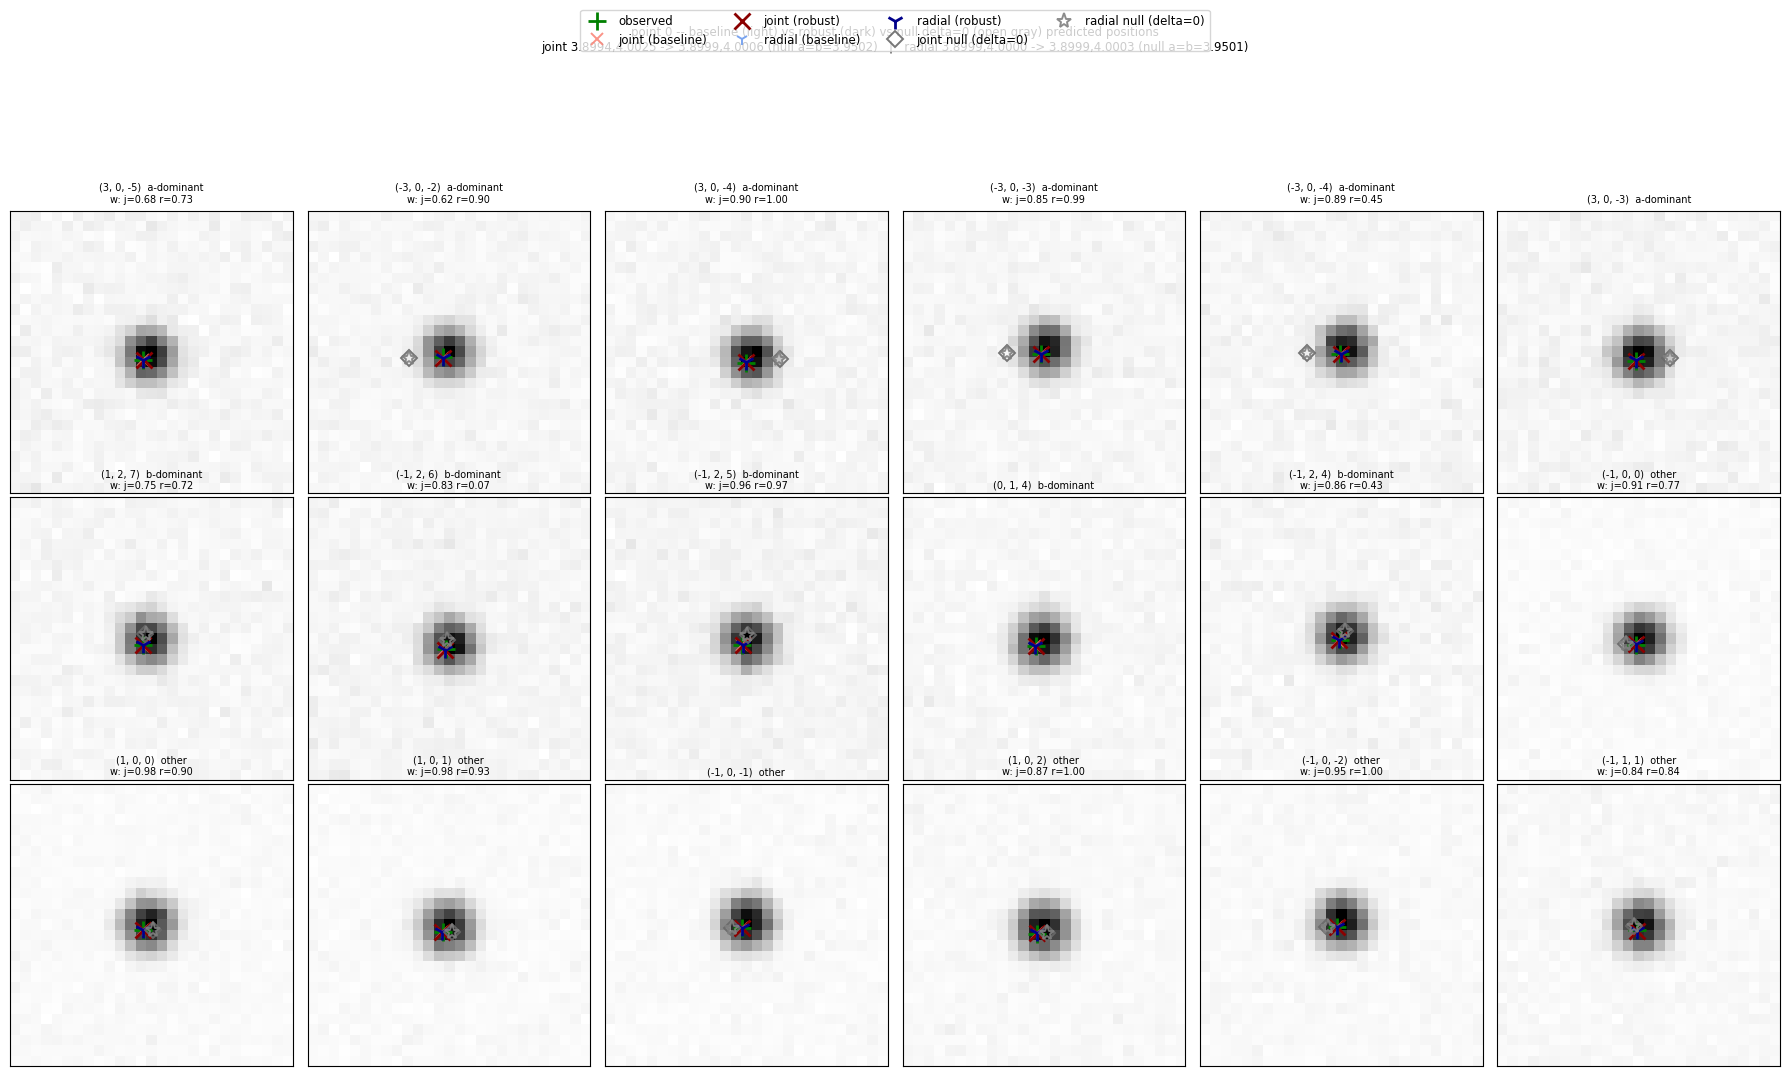

In [9]:
from midas_hkls.cell_constrained import refine_cell_joint_robust, refine_cell_radial_robust

if not res.domains.domains:
    print("No domains found at this position -- nothing to check. See res.notes.")
else:
    fj_rob = refine_cell_joint_robust(doms_, system="orthorhombic", cell0=SEED_CELL, two_pi=True,
                                      n_bootstrap=2000, rng=np.random.default_rng(0))
    fr_rob = refine_cell_radial_robust(doms_, system="orthorhombic", cell0=SEED_CELL, two_pi=True,
                                       n_bootstrap=2000, rng=np.random.default_rng(0))
    U_joint_rob = _rotvec_to_R(np.asarray(fj_rob.rotvecs[0]))
    # radial never fits an orientation -- Stage A's U_radial (from Step 7) applies to
    # the robust radial cell too, exactly as it did to the baseline one.

    sj_rob, sigj_rob, zj_rob = split_with_error(fj_rob)
    sr_rob, sigr_rob, zr_rob = split_with_error(fr_rob)
    print(f"joint   baseline: split={sj:.3f}% +/- {sigj:.3f}pp (z={zj:.2f})")
    print(f"joint   robust  : split={sj_rob:.3f}% +/- {sigj_rob:.3f}pp (z={zj_rob:.2f})  "
         f"[{fj_rob.robust_n_iter} IRLS iterations]")
    print(f"radial  baseline: split={sr:.3f}% +/- {sigr:.3f}pp (z={zr:.2f})")
    print(f"radial  robust  : split={sr_rob:.3f}% +/- {sigr_rob:.3f}pp (z={zr_rob:.2f})  "
         f"[{fr_rob.robust_n_iter} IRLS iterations]")

    # --- (1) refined lattice parameters at the last (robust) stage: a, b, c, V ---
    V_j = fj_rob.cell[0] * fj_rob.cell[1] * fj_rob.cell[2]
    V_r = fr_rob.cell[0] * fr_rob.cell[1] * fr_rob.cell[2]
    print(f"\nrefined lattice parameters (robust, last stage):")
    print(f"  joint : a={fj_rob.cell[0]:.4f} b={fj_rob.cell[1]:.4f} c={fj_rob.cell[2]:.4f} "
         f"V={V_j:.2f} A^3   (delta={sj_rob:.3f}%)")
    print(f"  radial: a={fr_rob.cell[0]:.4f} b={fr_rob.cell[1]:.4f} c={fr_rob.cell[2]:.4f} "
         f"V={V_r:.2f} A^3   (delta={sr_rob:.3f}%)")

    w_j, w_r = fj_rob.weights[0], fr_rob.weights[0]
    flagged_j = [i for i in range(len(hkl_all)) if w_j[i] < 0.7]
    flagged_r = [i for i in range(len(hkl_all)) if w_r[i] < 0.7]
    flagged_both = sorted(set(flagged_j) & set(flagged_r))
    print(f"\n{len(flagged_j)}/{len(hkl_all)} reflections downweighted (w<0.7) under JOINT, "
         f"{len(flagged_r)}/{len(hkl_all)} under RADIAL, "
         f"{len(flagged_both)} flagged by BOTH independently:")
    for i in flagged_both:
        print(f"  hkl={tuple(int(v) for v in hkl_all[i])!s:>16s}  w_joint={w_j[i]:.2f}  w_radial={w_r[i]:.2f}")
    print("(joint's weights skew lower than radial's even on CLEAN data -- see the "
         "calibration caveat in refine_cell_joint_robust's docstring; only agreement "
         "between the two is a strong signal, a low joint-only weight on its own is not)")

    # --- (2) the null (delta=0) prediction: same orientation, a=b forced to their
    # average, c left at the fit value -- isolates the split's OWN effect on pixel
    # position from everything else (orientation, c) held fixed ---
    a_avg_j = 0.5 * (fj_rob.cell[0] + fj_rob.cell[1])
    cell_null_j = (a_avg_j, a_avg_j, fj_rob.cell[2])
    a_avg_r = 0.5 * (fr_rob.cell[0] + fr_rob.cell[1])
    cell_null_r = (a_avg_r, a_avg_r, fr_rob.cell[2])

    d_null_j, d_fit_j, d_null_r, d_fit_r = [], [], [], []
    for i in has_both:
        hk = tuple(int(v) for v in hkl_all[i])
        row_o, col_o, frame_o = row_obs_all[i], col_obs_all[i], frame_obs_all[i]
        pnj = predict_pixel_for_hkl(cell_null_j, U_joint_rob, hk, frame_o)
        pfj = predict_pixel_for_hkl(fj_rob.cell, U_joint_rob, hk, frame_o)
        if pnj is not None:
            d_null_j.append(math.hypot(pnj[0]-row_o, pnj[1]-col_o))
        if pfj is not None:
            d_fit_j.append(math.hypot(pfj[0]-row_o, pfj[1]-col_o))
        pnr = predict_pixel_for_hkl(cell_null_r, U_radial, hk, frame_o)
        pfr = predict_pixel_for_hkl(fr_rob.cell, U_radial, hk, frame_o)
        if pnr is not None:
            d_null_r.append(math.hypot(pnr[0]-row_o, pnr[1]-col_o))
        if pfr is not None:
            d_fit_r.append(math.hypot(pfr[0]-row_o, pfr[1]-col_o))

    print(f"\neffect of forcing delta=0 (a=b={a_avg_j:.4f} for joint, {a_avg_r:.4f} for radial), "
         f"same orientation, over all {len(has_both)} matched reflections:")
    print(f"  joint : mean|null-obs|={np.mean(d_null_j):.2f}px vs mean|fit-obs|={np.mean(d_fit_j):.2f}px  "
         f"(null worse by {np.mean(d_null_j)-np.mean(d_fit_j):+.2f}px on average)")
    print(f"  radial: mean|null-obs|={np.mean(d_null_r):.2f}px vs mean|fit-obs|={np.mean(d_fit_r):.2f}px  "
         f"(null worse by {np.mean(d_null_r)-np.mean(d_fit_r):+.2f}px on average)")

    half_win = 13
    ncols, nrows = 6, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.6 * nrows))
    axes_flat = axes.ravel()
    for ax, (label, i) in zip(axes_flat, selection):
        hk = tuple(int(v) for v in hkl_all[i])
        row_o, col_o, frame_o = row_obs_all[i], col_obs_all[i], frame_obs_all[i]
        half_frames = max(3, int(np.ceil(n_frames_obs_all[i] / 2)) + 2)
        f_lo = max(0, int(round(frame_o)) - half_frames)
        f_hi = min(frames.shape[0], int(round(frame_o)) + half_frames + 1)
        r0, c0 = int(round(row_o)), int(round(col_o))
        r_lo, r_hi = max(0, r0 - half_win), min(frames.shape[1], r0 + half_win + 1)
        c_lo, c_hi = max(0, c0 - half_win), min(frames.shape[2], c0 + half_win + 1)
        patch = frames[f_lo:f_hi, r_lo:r_hi, c_lo:c_hi].astype(float).max(axis=0)
        ax.imshow(patch, origin="lower", cmap="gray_r", extent=[c_lo, c_hi, r_lo, r_hi],
                 vmax=max(patch.max(), 1))
        ax.plot(col_o, row_o, "g+", ms=13, mew=2.0, label="observed")

        pj0 = predict_pixel_for_hkl(fj.cell, U_joint, hk, frame_o)
        pj1 = predict_pixel_for_hkl(fj_rob.cell, U_joint_rob, hk, frame_o)
        pr0 = predict_pixel_for_hkl(fr.cell, U_radial, hk, frame_o)
        pr1 = predict_pixel_for_hkl(fr_rob.cell, U_radial, hk, frame_o)
        pnj = predict_pixel_for_hkl(cell_null_j, U_joint_rob, hk, frame_o)
        pnr = predict_pixel_for_hkl(cell_null_r, U_radial, hk, frame_o)
        if pj0 is not None:
            ax.plot(pj0[1], pj0[0], "x", color="salmon", ms=8, mew=1.4, alpha=0.85, label="joint (baseline)")
        if pj1 is not None:
            ax.plot(pj1[1], pj1[0], "x", color="darkred", ms=11, mew=2.0, label="joint (robust)")
        if pr0 is not None:
            ax.plot(pr0[1], pr0[0], "1", color="cornflowerblue", ms=9, mew=1.4, alpha=0.85, label="radial (baseline)")
        if pr1 is not None:
            ax.plot(pr1[1], pr1[0], "1", color="darkblue", ms=12, mew=2.0, label="radial (robust)")
        if pnj is not None:
            ax.plot(pnj[1], pnj[0], "D", mfc="none", mec="dimgray", ms=8, mew=1.4, alpha=0.9, label="joint null (delta=0)")
        if pnr is not None:
            ax.plot(pnr[1], pnr[0], "*", mfc="none", mec="gray", ms=11, mew=1.4, alpha=0.9, label="radial null (delta=0)")

        wtag = ""
        if w_j[i] < 0.99 or w_r[i] < 0.99:
            wtag = f"\nw: j={w_j[i]:.2f} r={w_r[i]:.2f}"
        ax.set_title(f"{hk}  {label}{wtag}", fontsize=7)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes_flat[len(selection):]:
        ax.axis("off")
    # collect legend entries across ALL panels, not just the first -- a marker type
    # that happened to have no valid prediction on axis 0 (e.g. the null cell falls
    # outside the forward model's allowed reflections for that one hkl) would
    # otherwise silently vanish from the legend even though it's plotted elsewhere.
    handles_by_label = {}
    for ax in axes_flat[:len(selection)]:
        h, l = ax.get_legend_handles_labels()
        for hi, li in zip(h, l):
            handles_by_label.setdefault(li, hi)
    fig.legend(list(handles_by_label.values()), list(handles_by_label.keys()), fontsize=8.5,
              loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0))
    fig.suptitle(f"point {POINT} -- baseline (light) vs robust (dark) vs null delta=0 (open gray) predicted positions\n"
                f"joint {fj.cell[0]:.4f},{fj.cell[1]:.4f} -> {fj_rob.cell[0]:.4f},{fj_rob.cell[1]:.4f} (null a=b={a_avg_j:.4f})   |   "
                f"radial {fr.cell[0]:.4f},{fr.cell[1]:.4f} -> {fr_rob.cell[0]:.4f},{fr_rob.cell[1]:.4f} (null a=b={a_avg_r:.4f})",
                fontsize=8.5, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.87])
    plt.show()

## Step 9 — Is the badness angle-dependent?

Step 8's bootstrap sigma is tight because it averages sub-pixel-precise
per-reflection noise over dozens of largely-independent reflections -- that
math cannot by itself tell a real, subtle lattice distortion apart from a
shared INSTRUMENTAL bias (detector distortion, absorption) that happens to
correlate with reflection type. One thing a real crystallographic split and a
2theta-dependent instrumental effect do NOT have in common: a genuine a/b
split's signature is set by which `hkl` direction a reflection probes, not by
its scattering angle. So: does this domain's residual (or its IRLS weight)
predict `|q|` -- the 2theta / detector-radius proxy?

**Read the correlation honestly, not as a verdict.** A real trend here would
be a specific, testable clue toward an instrumental explanation; a weak or
absent one does not clear the domain of the artifact concern already raised
by its own `index_asymmetry` and `decoy_test` failures -- it just means THIS
particular check didn't find a strong angle-dependence to chase. Whatever the
Pearson r comes out to be, report it as measured, not rounded up to "yes" or
down to "no."

joint (vector |g_pred-g_obs|): |q| vs |residual|  Pearson r=0.080, p=0.1547, slope=0.00039 (1/A per 1/A)
radial (||g_pred|-|g_obs||): |q| vs |residual|  Pearson r=0.038, p=0.4999, slope=0.00001 (1/A per 1/A)


/var/folders/qw/k6gzh2ws7w397493kq4vnl_w0001pb/T/ipykernel_43902/906362712.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.90])


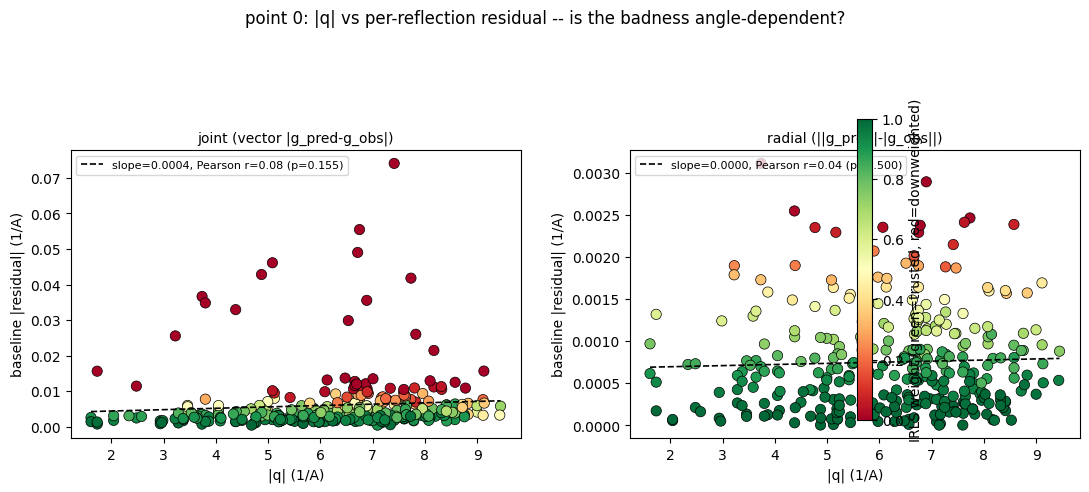


median |q| split at 6.632 1/A -- mean|residual|, low-Q half vs high-Q half:
  joint : 0.00496 vs 0.00714  (1.44x)
  radial: 0.00072 vs 0.00079  (1.10x)

(both Pearson r's here are weak -- at most a marginal trend for radial, essentially flat for joint. This does not confirm an angle-dependent instrumental cause; it also does not clear the domain of the artifact concern already on record. Treat as one more inconclusive data point, not a resolution.)


In [10]:
from midas_hkls.cell_constrained import _B_of
from scipy import stats

if not res.domains.domains:
    print("No domains found at this position -- nothing to check. See res.notes.")
else:
    qmag = np.linalg.norm(g_obs_domain, axis=1)

    Bj = _B_of(fj.cell + (90., 90., 90.), True)
    resid_j0 = np.linalg.norm((hkl_all.astype(float) @ (U_joint @ Bj).T) - g_obs_domain, axis=1)
    Br = _B_of(fr.cell + (90., 90., 90.), True)
    g_pred_mag_r = np.linalg.norm(hkl_all.astype(float) @ Br.T, axis=1)
    g_obs_mag = np.linalg.norm(g_obs_domain, axis=1)
    resid_r0 = np.abs(g_pred_mag_r - g_obs_mag)

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
    for ax, resid0, w, name in (
        (axes[0], np.abs(resid_j0), w_j, "joint (vector |g_pred-g_obs|)"),
        (axes[1], resid_r0, w_r, "radial (||g_pred|-|g_obs||)"),
    ):
        r0 = stats.pearsonr(qmag, resid0)
        sc = ax.scatter(qmag, resid0, c=w, cmap="RdYlGn", vmin=0, vmax=1, s=55,
                        edgecolor="k", linewidth=0.5)
        m, b = np.polyfit(qmag, resid0, 1)
        xx = np.linspace(qmag.min(), qmag.max(), 50)
        ax.plot(xx, m*xx + b, "k--", lw=1.2,
               label=f"slope={m:.4f}, Pearson r={r0[0]:.2f} (p={r0[1]:.3f})")
        ax.set_xlabel("|q| (1/A)"); ax.set_ylabel("baseline |residual| (1/A)")
        ax.set_title(name, fontsize=10)
        ax.legend(fontsize=8, loc="upper left")
        print(f"{name}: |q| vs |residual|  Pearson r={r0[0]:.3f}, p={r0[1]:.4f}, slope={m:.5f} (1/A per 1/A)")
    fig.colorbar(sc, ax=axes, label="IRLS weight (green=trusted, red=downweighted)", shrink=0.85)
    fig.suptitle(f"point {POINT}: |q| vs per-reflection residual -- is the badness angle-dependent?", y=1.06)
    fig.tight_layout(rect=[0, 0, 1, 0.90])
    plt.show()

    med = np.median(qmag)
    lo, hi = qmag <= med, qmag > med
    print(f"\nmedian |q| split at {med:.3f} 1/A -- mean|residual|, low-Q half vs high-Q half:")
    print(f"  joint : {np.mean(np.abs(resid_j0[lo])):.5f} vs {np.mean(np.abs(resid_j0[hi])):.5f}  "
         f"({np.mean(np.abs(resid_j0[hi]))/np.mean(np.abs(resid_j0[lo])):.2f}x)")
    print(f"  radial: {np.mean(resid_r0[lo]):.5f} vs {np.mean(resid_r0[hi]):.5f}  "
         f"({np.mean(resid_r0[hi])/np.mean(resid_r0[lo]):.2f}x)")
    print("\n(both Pearson r's here are weak -- at most a marginal trend for radial, "
         "essentially flat for joint. This does not confirm an angle-dependent "
         "instrumental cause; it also does not clear the domain of the artifact "
         "concern already on record. Treat as one more inconclusive data point, "
         "not a resolution.)")

## What one position can and cannot tell you

- **One position, one gauge.** "a" and "b" are an arbitrary label per domain (a 4-fold or
  mirror symmetry can swap them) -- never compare the SIGN of a split across domains or
  positions without checking the axis convention first.
- **`quotable=True` here means the documented per-position gates passed, not that the number is
  final.** A radial-systematic error can pass every gate above and still manufacture a splitting
  with a consistent sign across domains -- that signature is only visible ACROSS several
  domains/positions. Run `06_raster_lattice_batch.ipynb`'s raster-wide check before quoting
  anything from this notebook alone.
- **Geometry is fixed, not fitted here.** `reduce_one_position` does not self-calibrate; if you
  do not trust the seed geometry, run `midas_defect.selfcal.selfcalibrate_from_crystals`
  separately and inspect it (it has no convergence guarantee).
- **This position's cell is not pooled with any other.** Refining several domains or positions
  JOINTLY against one shared cell is a further, separate analysis
  (`manuals/solve-cell/phase-3-refine.md`), deliberately not automated here.
